In [1]:
from parameters import *
pd.set_option('display.max_rows', None)

In [8]:
df = pd.read_excel(PATH)
df_parametros = pd.read_excel(PATH, sheet_name='Parâmetros')

df['Data'] = pd.to_datetime(df['Data'])

#Criacao das novas colunas
df['Categoria'] = df['Local'].map(
    df_parametros.set_index('Local')['Categoria']
).fillna('Extra')

df['Pagamento?'] = np.where(
    (df['Local'] == "CERN") & (df['Valor'] > 3000),
    "Sim",
    "Não"
)
df['Mês Pagamento'] = np.where(
    df['Data'].dt.day >= 25, 
    (df['Data'] + pd.DateOffset(months=1)), 
    df['Data']
)
df['Mês Pagamento'] = df['Mês Pagamento'].dt.strftime('%m/%y')


saldo = []
for i, row in df.iterrows():
    if i == 0:
        saldo_atual = 3486

    elif row['Pagamento?'] == 'Sim':
        saldo_atual = 3486

    else:
        saldo_atual = saldo[-1] - row['Valor']
    
    saldo.append(saldo_atual)

df['Saldo'] = saldo

print(MES_ATUAL)


df['Mês Pagamento Atual?'] = np.where(df['Mês Pagamento'] == MES_ATUAL, 'Sim', 'Não')

df.tail(50)


03/26


,Data,Local,Valor,Categoria,Pagamento?,Mês Pagamento,Saldo,Mês Pagamento Atual?
81,2026-02-23,McDonalds,8.600000,Lanche,Não,02/26,4.320000,Não
82,2026-02-24,Denner,1.700000,Mercado,Não,02/26,2.620000,Não
83,2026-02-26,CERN,3486.000000,Alimentação,Sim,03/26,3486.000000,Sim
84,2026-02-26,Carrefour,68.983264,Mercado,Não,03/26,3417.016736,Sim
85,2026-02-26,SOCAR,3.100000,Extra,Não,03/26,3413.916736,Sim
86,2026-02-26,Denner,12.500000,Mercado,Não,03/26,3401.416736,Sim
87,2026-02-26,Coop,11.000000,Mercado,Não,03/26,3390.416736,Sim
88,2026-02-26,McDonalds,14.900000,Lanche,Não,03/26,3375.516736,Sim
89,2026-02-26,NonStop,49.000000,Fixo,Não,03/26,3326.516736,Sim
90,2026-02-26,Digitec,19.900000,Extra,Não,03/26,3306.616736,Sim


### Gastos por Dia

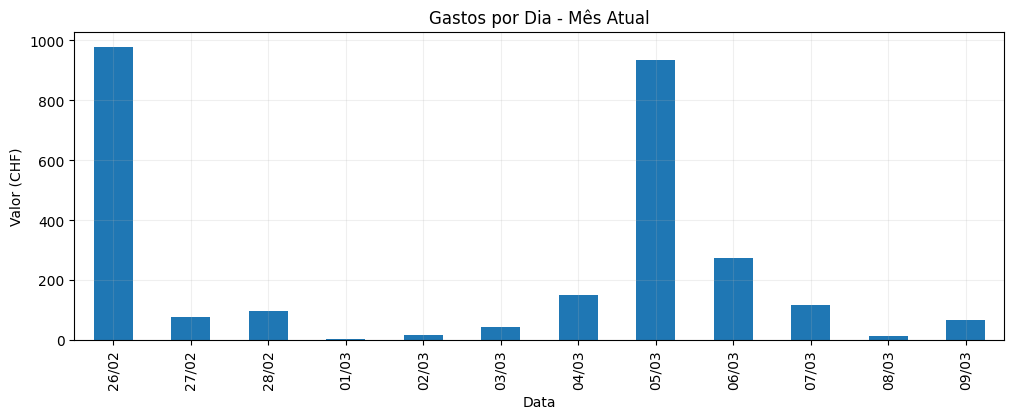

In [10]:
# Filtrando dados que não são pagamentos
df_gastos = df[(df['Pagamento?'] == 'Não') & (df['Mês Pagamento Atual?'] == "Sim")]

# Soma de gastos por dia
gastos_por_dia = df_gastos.groupby('Data')['Valor'].sum()
gastos_por_dia.index = gastos_por_dia.index.strftime('%d/%m') #Conversão do formato de data (dd/mm/yyyy -> dd/mm)

plt.figure(figsize=(12,4))
ax = gastos_por_dia.plot(kind='bar')

plt.title('Gastos por Dia - Mês Atual')
plt.xlabel('Data')
plt.ylabel('Valor (CHF)')
plt.grid(alpha=0.2)
plt.show()



### Gastos por Categoria

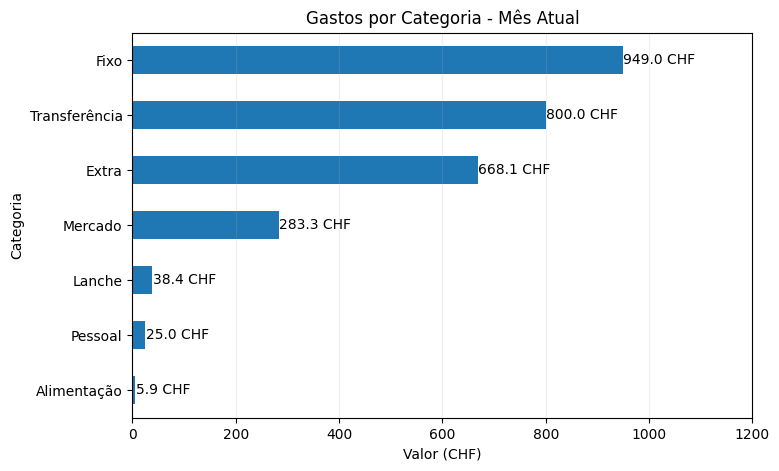

In [12]:
gastos_categoria = df_gastos.groupby('Categoria')['Valor'].sum().sort_values(ascending=True)

ax = gastos_categoria.plot(kind='barh', figsize=(8,5))
plt.title('Gastos por Categoria - Mês Atual')
plt.xlabel('Valor (CHF)')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)
plt.xlim([0, 1200])

for i, v in enumerate(gastos_categoria.values):
    ax.text(v + 1, i, f'{v:.1f} CHF', va='center')
plt.show()
